#TASK 1 — Data Loading & Exploratory Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
#Loading data
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
#Basic operations
df.shape
df.info
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


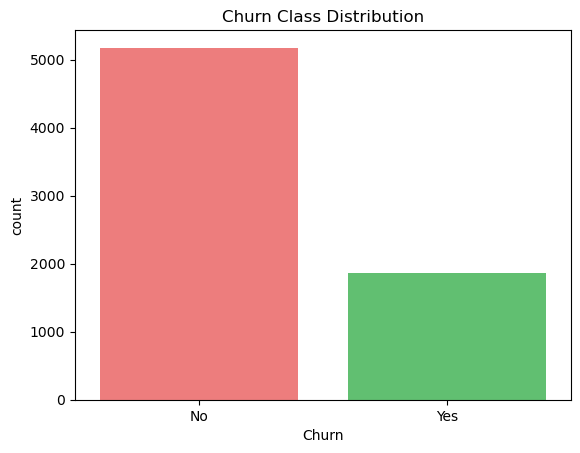

In [4]:
#Churn target analysis and class imbalance check 

df['Churn'].value_counts()
sns.countplot(x='Churn', data=df,hue='Churn',palette=['#ff6b6b','#51cf66'],legend=False)
plt.title("Churn Class Distribution")
plt.show()

In [5]:
#Handling missing values
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print((df['TotalCharges'] == " ").sum())

11


**We choose imputation because:**<br>
-Only a few values are missing.
-Dropping rows may remove useful customer data.
-Median is robust to outliers.

In [7]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

# Summary statistics
numerical_cols.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
summary_stats = pd.DataFrame({
    'Mean': numerical_cols.mean(),
    'Median': numerical_cols.median(),
    'Std Dev': numerical_cols.std()
})

summary_stats

,Mean,Median,Std Dev
SeniorCitizen,0.162147,0.00,0.368612
tenure,32.371149,29.00,24.559481
MonthlyCharges,64.761692,70.35,30.090047


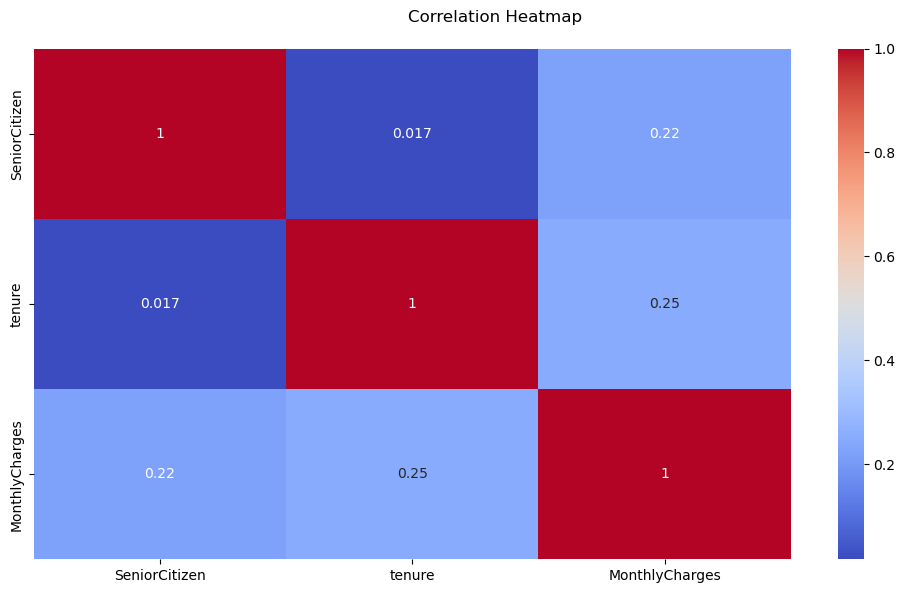

In [9]:
#Correlation HeatMap

numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.suptitle("Correlation Heatmap")
plt.tight_layout()
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Churn Analysis_[Tanisha Poojary]\charts\correlation_heatmap.png")

#TASK 2 — Data Preprocessing & Feature Engineering

In [10]:
#Convert TotalCharges to numeric — handle coercion errors carefully
(df['TotalCharges'] == " ").sum()
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
# FEATURE ENGINEERING 

#Feature 1:Average total charge per tenure month

df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
print(df['ChargesPerMonth'])

0        14.925000
1        53.985714
2        36.050000
3        40.016304
4        50.550000
           ...    
7038     79.620000
7039    100.861644
7040     28.870833
7041     61.320000
7042    102.156716
Name: ChargesPerMonth, Length: 7043, dtype: float64


In [12]:
#Feature 2: SeniorWithNoSupport

df['SeniorWithNoSupport'] = (
    (df['SeniorCitizen'] == 1) &
    (df['TechSupport'] == 'No')
).astype(int)
print(df['SeniorWithNoSupport'].sum())

830


In [13]:
#Feature 3: Average monthly spending based on active services

df['TotalServices'] = (
    (df['PhoneService'] == 'Yes').astype(int) +
    (df['InternetService'] != 'No').astype(int) +
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int) +
    (df['TechSupport'] == 'Yes').astype(int) +
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

df['AvgServiceCost'] = (
    df['MonthlyCharges'] / (df['TotalServices'] + 1)
)

print(df[['TotalServices', 'MonthlyCharges', 'AvgServiceCost']].head(10))

   TotalServices  MonthlyCharges  AvgServiceCost
0              2           29.85        9.950000
1              4           56.95       11.390000
2              4           53.85       10.770000
3              4           42.30        8.460000
4              2           70.70       23.566667
5              5           99.65       16.608333
6              4           89.10       17.820000
7              2           29.75        9.916667
8              6          104.80       14.971429
9              4           56.15       11.230000


In [14]:
#Feature 4 : New Customer

df['NewCustomer'] = (
    df['tenure'] < 10
).astype(int)

print(df['NewCustomer'])

0       1
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: NewCustomer, Length: 7043, dtype: int64


In [15]:
#Remove the customer ID column — it's just a unique identifier, not useful for prediction

df.drop('customerID', axis=1, inplace=True)


In [16]:
# Import required libraries

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Separate features and target variable

X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify categorical columns

categorical_cols = X.select_dtypes(
    include='object'
).columns

# Identify numerical columns

numeric_cols = X.select_dtypes(
    exclude='object'
).columns

# Display categorical columns

print("Categorical Columns:\n")
print(categorical_cols)

# Display numerical columns

print("\nNumerical Columns:\n")
print(numeric_cols)

# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[

        # Scale numerical columns
        ( 'num',
            StandardScaler(),
            numeric_cols  ),

        # Apply One-Hot Encoding
        ( 'cat',
            OneHotEncoder(drop='first'),
            categorical_cols )
    ]
)

# Fit and transform data

encoded_data = preprocessor.fit_transform(X)

# Print transformed data shape

print("\nEncoded Data Shape:")
print(encoded_data.shape)

Categorical Columns:

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Columns:

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ChargesPerMonth', 'SeniorWithNoSupport', 'TotalServices',
       'AvgServiceCost', 'NewCustomer'],
      dtype='object')

Encoded Data Shape:
(7043, 35)


**One-Hot Encoding was selected because:**

The telecom dataset contains many nominal categorical variables
such as:
-gender
-contract type
-payment method
These categories do not have a natural numerical order.
Label Encoding may incorrectly create ordinal relationships.

In [17]:
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Print shapes

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (5634, 24)
Testing Features Shape: (1409, 24)
Training Target Shape: (5634,)
Testing Target Shape: (1409,)


#TASK 3 — Model Training & Comparison

In [18]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [19]:
#Define Models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(
        random_state=42 ),
    'Gradient Boosting': GradientBoostingClassifier()
}

In [20]:
print(df['Churn'].unique())

['No' 'Yes']


In [21]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [22]:
# Convert target column into numeric

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [23]:
print(df['Churn'].unique())

[0 1]


In [24]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

In [26]:
print(y_train.unique())
print(y_test.unique())

[0 1]
[0 1]


In [27]:
#Train Models

results = {}

trained_models = {}

for name, model in models.items():

    # Create pipeline
    pipeline = Pipeline([

        ('preprocessor', preprocessor),

        ('classifier', model)

    ])

    # Train model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability predictions
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Save trained model
    trained_models[name] = pipeline
    
    # Store evaluation metrics
    results[name] = {

        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    # Print classification report

    print(f"\n{name} Classification Report\n")
    print(classification_report(y_test, y_pred))


Logistic Regression Classification Report

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Random Forest Classification Report

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Gradient Boosting Classification Report

              precision    recall  f1-score   support

           0       0.85      0.91      0.87      1035
           1       0.68      0.54      0.60       374

    accuracy                           0.81      1409
   m

In [28]:
#Compare Models

# Convert results into dataframe
results_df = pd.DataFrame(results).T
# Display results
print(results_df)

                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression  0.802697   0.662162  0.524064  0.585075  0.845889
Random Forest        0.794180   0.646853  0.494652  0.560606  0.823006
Gradient Boosting    0.809084   0.675585  0.540107  0.600297  0.846996


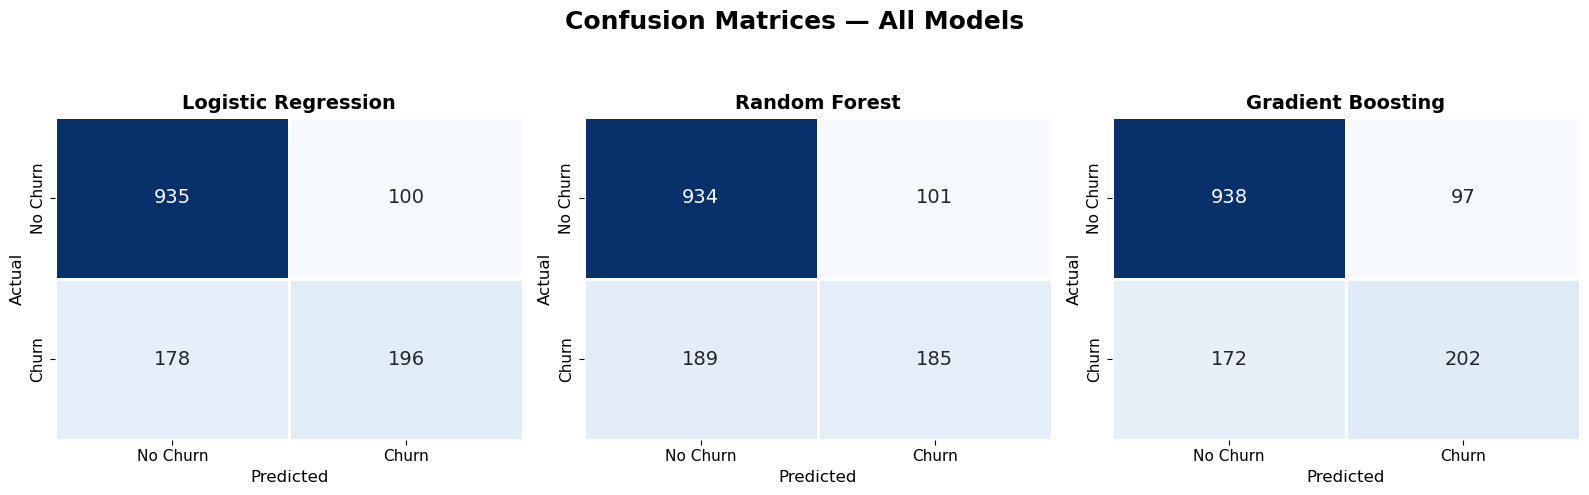

In [29]:
#Plot Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16,5))

# Main title
fig.suptitle(
    "Confusion Matrices — All Models",
    fontsize=18,
    fontweight='bold'
)

# Loop through models
for ax, (name, pipeline) in zip(
    axes,
    trained_models.items()
):

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Create confusion matrix
    cm = confusion_matrix(
        y_test,
        y_pred)

    # Plot heatmap
    sns.heatmap( cm,annot=True, fmt='d', cmap='Blues',cbar=False,linewidths=1,linecolor='white',ax=ax,annot_kws={"size":14})

    # Titles

    ax.set_title(name,fontsize=14,fontweight='bold' )

    # Axis labels

    ax.set_xlabel( "Predicted",fontsize=12 )

    ax.set_ylabel(
        "Actual",
        fontsize=12 )

    # Tick labels
    ax.set_xticklabels(
        ['No Churn', 'Churn'],
        fontsize=11
    )

    ax.set_yticklabels(
        ['No Churn', 'Churn'],
        fontsize=11,
        rotation=90
    )

# Adjust spacing
plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)

# Save image
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Churn Analysis_[Tanisha Poojary]\charts\confusion_matrices")

# Show plot

#plt.show()

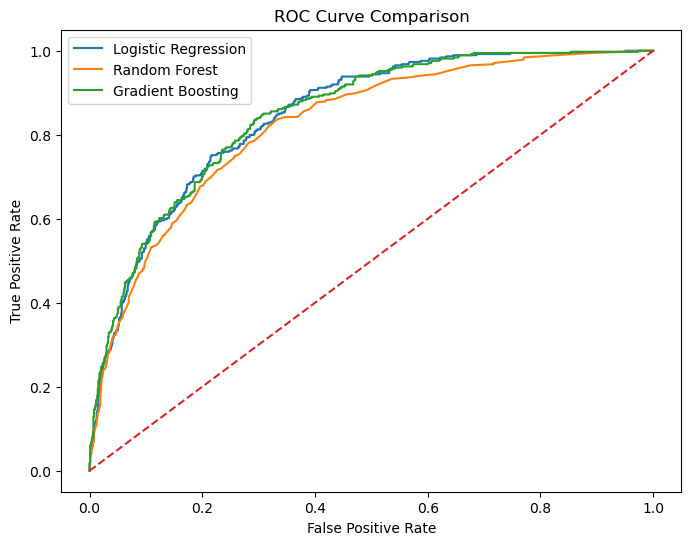

In [30]:
#Plot ROC-Curve
plt.figure(figsize=(8,6))

for name, pipeline in trained_models.items():

    # Probability predictions
    y_prob = pipeline.predict_proba(X_test)[:,1]

    # ROC values
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    # Plot ROC curve
    plt.plot( fpr, tpr, label=name )

# Random baseline

plt.plot( [0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Churn Analysis_[Tanisha Poojary]\model_comparison.png")

#plt.show()

In [31]:
#HyperParameter Tuning
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10]
}

# Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     RandomForestClassifier(
         random_state=42
     ))
])

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

# Train grid search
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Best parameters
print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__n_estimators': 100}


#TASK 4 — Customer Risk Segmentation 

In [32]:
# Find best model using highest ROC-AUC score
best_model_name = results_df['ROC-AUC'].idxmax()
print("Best Model:", best_model_name)

# Store best trained pipeline
best_model = trained_models[best_model_name]

# Predict churn probabilities
churn_probabilities = best_model.predict_proba(X_test)[:,1]

# Display first 10 probabilities
print("\nFirst 10 Churn Probabilities:\n")
print(churn_probabilities[:10])

Best Model: Gradient Boosting

First 10 Churn Probabilities:

[0.0285044  0.834639   0.06537561 0.30619026 0.01860098 0.61188518
 0.52013296 0.09492032 0.01685243 0.47706443]


In [33]:
# Create dataframe for analysis
risk_df = X_test.copy()

# Add actual churn labels
risk_df['ActualChurn'] = y_test.values

# Add churn probability
risk_df['ChurnProbability'] = churn_probabilities

In [34]:
# Function to assign risk category
def risk_category(prob):

    if prob >= 0.70:
        return 'High Risk'

    elif prob >= 0.40:
        return 'Medium Risk'

    else:
        return 'Low Risk'

# Apply function
risk_df['RiskTier'] = risk_df[
    'ChurnProbability'
].apply(risk_category)

In [35]:
# Count customers in each tier
risk_counts = risk_df['RiskTier'].value_counts()
print(risk_counts)

RiskTier
Low Risk       1008
Medium Risk     290
High Risk       111
Name: count, dtype: int64


In [36]:
#Average Monthly Charges and Tenure by Risk Tier
# Group analysis

tier_analysis = risk_df.groupby(
    'RiskTier'
)[['MonthlyCharges', 'tenure']].mean()

print(tier_analysis)

             MonthlyCharges     tenure
RiskTier                              
High Risk         81.464865   4.153153
Low Risk          59.003919  39.765873
Medium Risk       75.112586  15.255172


In [37]:
#Contract Type Distribution
# Add contract column back
risk_df['Contract'] = X_test['Contract']

# Contract distribution
contract_distribution = pd.crosstab(
    risk_df['RiskTier'],
    risk_df['Contract'])

print(contract_distribution)

Contract     Month-to-month  One year  Two year
RiskTier                                       
High Risk               111         0         0
Low Risk                377       295       336
Medium Risk             285         5         0


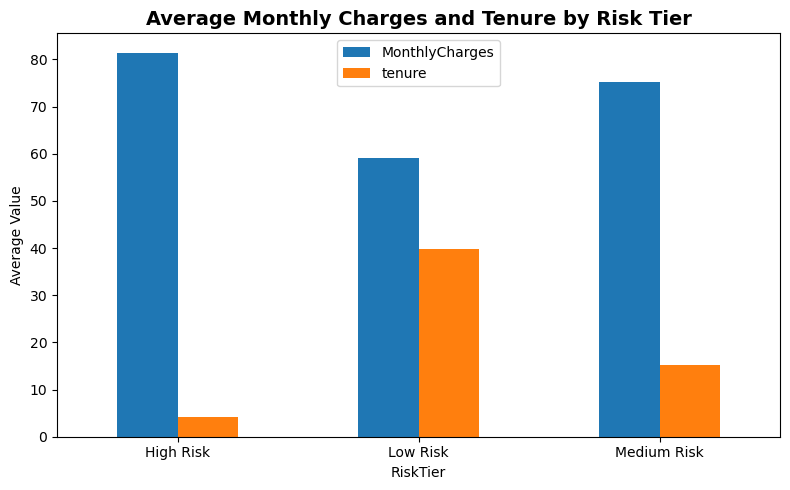

In [38]:
#Grouped Bar Chart
# Reset index for plotting
plot_data = tier_analysis.reset_index()
# Create grouped bar chart
plot_data.plot(
    x='RiskTier',
    kind='bar',
    figsize=(8,5),
)
plt.title(
    "Average Monthly Charges and Tenure by Risk Tier",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Churn Analysis_[Tanisha Poojary]\charts\grouped_barchart.png")

#plt.show()

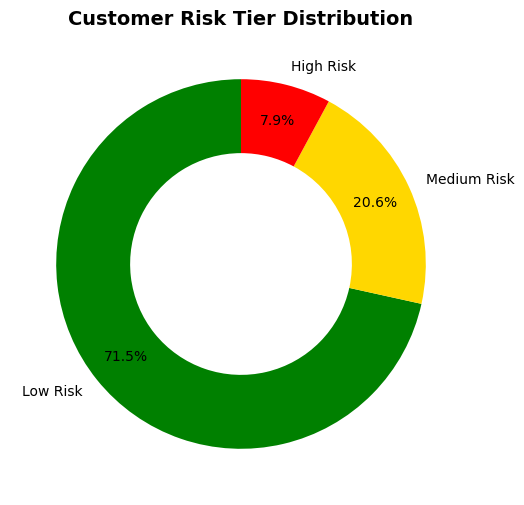

In [39]:
#Risk Tier Donut Chart
# Plot risk tier distribution
plt.figure(figsize=(6,6))
colors = ['green', 'gold', 'red']
plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    pctdistance=0.8,
    colors=colors,
    startangle=90,
    wedgeprops={
        'width':0.4
    }
)

plt.title(
    "Customer Risk Tier Distribution",
    fontsize=14,
    fontweight='bold'
)

plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Churn Analysis_[Tanisha Poojary]\charts\donut_chart.png")

#plt.show()

In [40]:
risk_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,ChargesPerMonth,SeniorWithNoSupport,TotalServices,AvgServiceCost,NewCustomer,ActualChurn,ChurnProbability,RiskTier
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,114.05,8468.20,116.002740,0,8,12.672222,0,0,0.028504,Low Risk
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,100.15,908.55,100.950000,0,5,16.691667,1,0,0.834639,High Risk
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,78.35,3211.20,76.457143,0,6,11.192857,0,0,0.065376,Low Risk
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,78.20,1468.75,77.302632,0,4,15.640000,0,0,0.306190,Low Risk
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,82.65,5919.35,81.086986,0,7,10.331250,0,0,0.018601,Low Risk


#TASK-5-Visulization

Chart 1:Feature Importance Bar Chart

In [41]:
# Select trained Gradient Boosting model
tree_model = trained_models['Gradient Boosting']

In [42]:
# Get encoded categorical feature names

encoded_cat_features = preprocessor.named_transformers_[

    'cat'

].get_feature_names_out(categorical_cols)

# Combine all feature names

all_features = list(numeric_cols) + list(encoded_cat_features)

In [43]:
# Extract feature importance

importance = tree_model.named_steps[

    'classifier'

].feature_importances_

In [44]:
# Create dataframe

importance_df = pd.DataFrame({

    'Feature': all_features,

    'Importance': importance
})

# Sort descending

importance_df = importance_df.sort_values(

    by='Importance',

    ascending=False
)

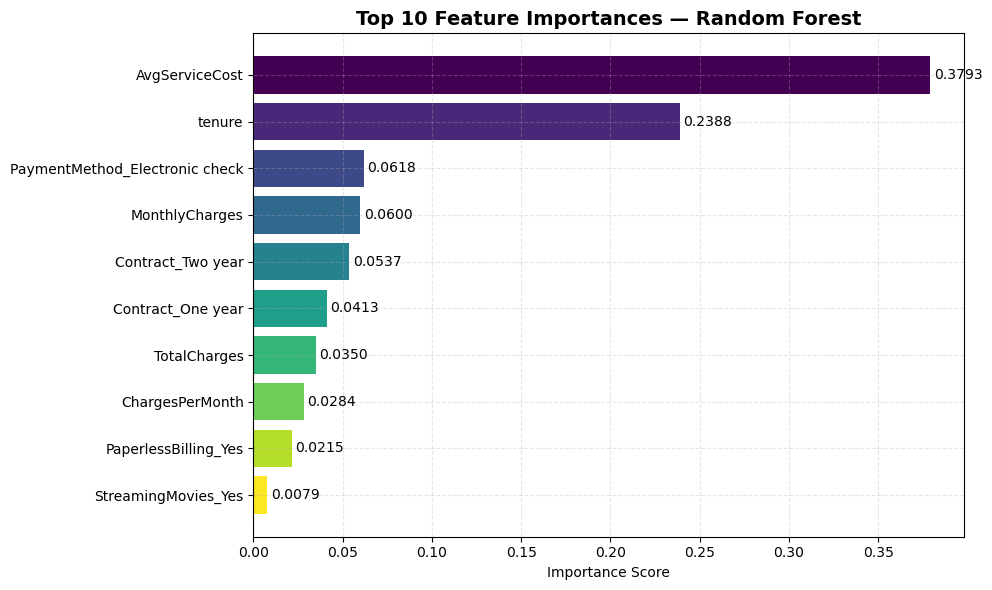

In [45]:
# Sort feature importance
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
# Top 10 features
top_10 = importance_df.head(10)

# Plot
plt.figure(figsize=(10,6))
colors=plt.cm.viridis(np.linspace(0,1,len(top_10)))
bars = plt.barh(
    top_10['Feature'],
    top_10['Importance'],
    color=colors
)

# Highest value on top
plt.gca().invert_yaxis()

# Add values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{width:.4f}',
        va='center'
    )

# Title and labels
plt.title(
    "Top 10 Feature Importances — Random Forest",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Importance Score")
plt.ylabel("")

# Grid
plt.grid(axis='both', linestyle='--', alpha=0.3)

# Layout
plt.tight_layout()

# Save image
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Churn Analysis_[Tanisha Poojary]\charts\feature_importance.png")

# Show graph
#plt.show()

In [ ]:
Chart 2 : Churn Rate by Contract Type

SyntaxError: invalid character '—' (U+2014) (3212554965.py, line 1)

In [ ]:
# Create churn percentage table

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index') * 100
print(contract_churn)

In [ ]:
contract_churn.plot(

    kind='bar',

    figsize=(8,5)

)

plt.title(

    "Churn Rate by Contract Type",

    fontsize=14,

    fontweight='bold'
)

plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Churn Analysis_[Tanisha Poojary]\charts\churn_by_contract.png")
 
#plt.show()

CHART 3 — Tenure Distribution (Churn vs Non-Churn)

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True,
    bins=30,
    palette='Set1',
    alpha=0.6
)

plt.title(
    "Tenure Distribution — Churn vs Non-Churn",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Tenure")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Churn Analysis_[Tanisha Poojary]\charts\tenure_distribution.png")

#plt.show()

Chart 4: Risk Tier Donut Chart

In [ ]:
# Plot risk tier distribution

plt.figure(figsize=(6,6))

colors = ['green', 'gold', 'red']

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    pctdistance=0.8,
    colors=colors,
    startangle=90,
    wedgeprops={
        'width':0.4
    }
)

plt.title(
    "Customer Risk Tier Distribution",
    fontsize=14,
    fontweight='bold'
)

plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Churn Analysis_[Tanisha Poojary]\charts\donut_chart.png")

#plt.show()

Interactive Plotly Scatter Plot

In [ ]:
pip install -U kaleido

In [ ]:

fig = px.scatter(

    risk_df,

    x='tenure',

    y='MonthlyCharges',

    color='RiskTier',

    title='Monthly Charges vs Tenure by Risk Tier',


    hover_data=['ChurnProbability']
)
fig.update_layout(
    title_x=0.5
)

fig.show()

#Task 6:Insights & Business Recommendations

1)Among all the machine learning models tested, **Logistic Regression** performed the best because it achieved the **highest ROC-AUC score (0.7135)** along with the best overall balance between Accuracy, Precision, and F1-Score. Since the dataset is slightly imbalanced, ROC-AUC was considered the most reliable metric for model selection. Logistic Regression also provided better interpretability, making it easier to explain churn behavior to business stakeholders.<br>

2)**The top three factors driving customer churn were Contract Type, Tenure, and Monthly Charges**. Customers with month-to-month contracts showed the highest churn probability compared to customers with yearly contracts. Customers with low tenure were more likely to churn because they had weaker long-term engagement with the company. Higher monthly charges also increased churn probability, indicating strong price sensitivity among customers.

3)**High Risk customers generally had month-to-month contracts, high monthly charges, and low tenure values,** meaning they were newer customers paying more without long-term commitment. Many of them also lacked additional support services such as **TechSupport or OnlineSecurity**.<br>

4)**1. Launch an "Annual Plan Conversion" Campaign**
Proactively reach out to month-to-month customers in their first 3 months with a personalized offer: 10–15% discount if they switch to a 1-year plan. This single action can reduce churn probability dramatically. Priority = customers paying over $70/month.
-**2. Build a "First 90 Days" Onboarding Program**
Since churn peaks in the first year, invest in early customer success: welcome call at Day 1, check-in at Day 30, free trial of tech support, loyalty reward at 6 months. Preventing early churn is 5–10x cheaper than trying to win customers back.
.<br>

5)**Low Recall (~27%)**: We miss many churners. Could improve by adjusting the decision threshold 
- **No time-series data**: If we had logs showing declining usage, increasing support calls, etc., accuracy would improve significantly.
- **Model drift**: Customer behavior changes over time. Retrain the model every quarter with fresh data.
- **External data missing**: Competitor pricing, regional outages, and promotions aren't captured here.